In [9]:
import requests
import pandas as pd
import time

def fetch_balanced_github_issues(owner, repo, labels, issues_per_label=150):
    print(f"Starting targeted search for {owner}/{repo}...")
    issues_data = []

    for label in labels:
        print(f"\nHunting for '{label}' issues...")
        page = 1
        collected_for_label = 0

        while collected_for_label < issues_per_label:
            url = "https://api.github.com/search/issues"
            query = f"repo:{owner}/{repo} label:\"{label}\" state:closed type:issue"
            params = {"q": query, "per_page": 100, "page": page}

            response = requests.get(url, params=params)

            if response.status_code == 403:
                print("Rate limit hit! Waiting 60 seconds...")
                time.sleep(60)
                continue
            elif response.status_code != 200:
                print(f"Error fetching {label}: {response.status_code}")
                break

            data = response.json()
            items = data.get("items", [])

            if not items:
                print(f"No more items found for {label}.")
                break

            for issue in items:
                issue_labels = [l['name'] for l in issue.get('labels', [])]

                overlap = [l for l in issue_labels if l in labels]

                if len(overlap) == 1:
                    issues_data.append({
                        "title": issue['title'],
                        "body": issue['body'],
                        "label": label
                    })
                    collected_for_label += 1

                if collected_for_label >= issues_per_label:
                    break
            print(f"Page {page} processed. Total '{label}' collected: {collected_for_label}/{issues_per_label}")
            page += 1
            time.sleep(3)

    return pd.DataFrame(issues_data)

REPO_OWNER = "scikit-learn"
REPO_NAME = "scikit-learn"
TARGET_LABELS = ["Bug", "Enhancement", "Documentation"]

df_issues = fetch_balanced_github_issues(REPO_OWNER, REPO_NAME, TARGET_LABELS, issues_per_label=150)

df_issues = df_issues.dropna(subset=['body'])

df_issues.to_csv("github_issues_dataset.csv", index=False)

print("\nTargeted Scraping Complete! Here is your balanced dataset:")
display(df_issues.head())
print(f"\nLabel Distribution:\n{df_issues['label'].value_counts()}")

Starting targeted search for scikit-learn/scikit-learn...

Hunting for 'Bug' issues...
Page 1 processed. Total 'Bug' collected: 96/150
Page 2 processed. Total 'Bug' collected: 150/150

Hunting for 'Enhancement' issues...
Page 1 processed. Total 'Enhancement' collected: 87/150
Page 2 processed. Total 'Enhancement' collected: 150/150

Hunting for 'Documentation' issues...
Page 1 processed. Total 'Documentation' collected: 90/150
Page 2 processed. Total 'Documentation' collected: 150/150

Targeted Scraping Complete! Here is your balanced dataset:


,title,body,label
0,HTML display parameter/attribute links don't w...,### Describe the bug and give evidence about i...,Bug
1,BUG HTML Display not showing output features f...,### Describe the bug and give evidence about i...,Bug
2,MLPClassifier with early_stopping=True crashes...,### Describe the bug and give evidence about i...,Bug
3,bhjmbgjh,### Describe the bug and give evidence about i...,Bug
4,Unnecessary y.ndim check and separate array tr...,### Describe the bug and give evidence about i...,Bug



Label Distribution:
label
Bug              150
Enhancement      150
Documentation    149
Name: count, dtype: int64


In [10]:
import re
import nltk
from nltk.corpus import stopwords
import pandas as pd

print("Downloading NLTK stopwords...")
nltk.download('stopwords', quiet = True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
  if not isinstance(text, str):
    return ""
  text = re.sub(r'```.*?```', ' ', text, flags = re.DOTALL)
  text = re.sub(r'`.*?`', ' ', text)
  text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags = re.MULTILINE)
  text = re.sub(r'#+', ' ', text)
  text = re.sub(r'\*\*|\*|__|_', ' ', text)
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)
  words = text.lower().split()
  cleaned_words = [w for w in words if w not in stop_words and len(w) > 2]
  return " ".join(cleaned_words)

print("🧹 Merging titles and bodies, and cleaning the text. This might take a few seconds...")
df_issues['full_text'] = df_issues['title'] + " " + df_issues['body']
df_issues['cleaned_text'] = df_issues['full_text'].apply(clean_text)
df_issues = df_issues[df_issues['cleaned_text'].str.strip().astype(bool)]

🧹 Merging titles and bodies, and cleaning the text. This might take a few seconds...


Preparing data for the machine learning model...
Data split: 359 rows for training, 90 rows for testing.
Training the Logistic Regression model...
Making predictions on the test set...

              MODEL REPORT CARD
               precision    recall  f1-score   support

          Bug       0.91      0.83      0.87        35
Documentation       0.96      0.90      0.93        30
  Enhancement       0.77      0.92      0.84        25

     accuracy                           0.88        90
    macro avg       0.88      0.88      0.88        90
 weighted avg       0.89      0.88      0.88        90



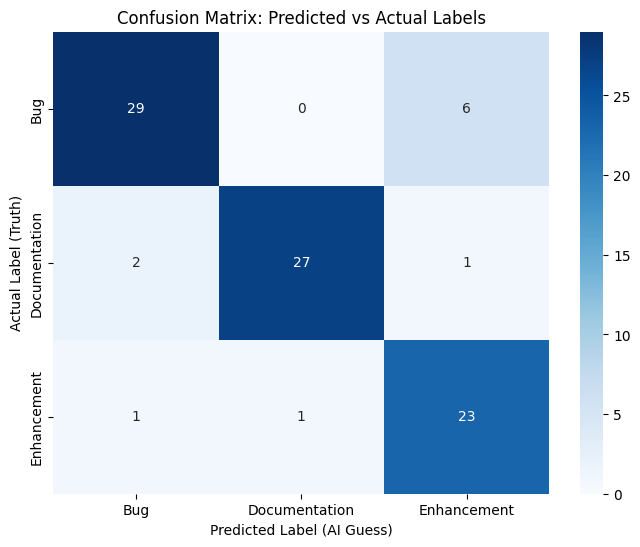

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Preparing data for the machine learning model...")
X = df_issues['cleaned_text']
y = df_issues['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Data split: {len(X_train)} rows for training, {len(X_test)} rows for testing.")

vectorizer = TfidfVectorizer(max_features = 5000)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print("Training the Logistic Regression model...")
model = LogisticRegression(random_state = 42, max_iter = 1000)
model.fit(X_train_vectorized, y_train)

print("Making predictions on the test set...")
y_pred = model.predict(X_test_vectorized)

print("\n" + "=" * 50)
print("              MODEL REPORT CARD")
print("=" * 50)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels = model.classes_)

plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = model.classes_, yticklabels = model.classes_)
plt.title('Confusion Matrix: Predicted vs Actual Labels')
plt.ylabel('Actual Label (Truth)')
plt.xlabel('Predicted Label (AI Guess)')
plt.show()

In [16]:
def predict_new_issue(title, body):
    raw_text = title + " " + body
    cleaned = clean_text(raw_text)
    vectorized_text = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized_text)[0]
    probabilities = model.predict_proba(vectorized_text)[0]
    print("\n" + "=" * 55)
    print("-----AI Issue Triage System-----")
    print("=" * 55)
    print(f"Issue Title: '{title}'\n")
    print(f"Predicted Label: {prediction.upper()}")
    print("-" * 55)
    print("Confidence Breakdown:")
    for cls, prob in zip(model.classes_, probabilities):
        print(f"  - {cls:<15}: {prob*100:.1f}%")
    print("=" * 55 + "\n")

In [17]:
# Scenario 1: A clear bug
bug_title = "RandomForestClassifier crashes on sparse matrices"
bug_body = "When I pass a scipy.sparse matrix to the fit() method, I get a ValueError. Dense arrays work perfectly fine though. Please fix!"
predict_new_issue(bug_title, bug_body)

# Scenario 2: A documentation request
doc_title = "Typo in the Quickstart Guide"
doc_body = "On page 3 of the installation instructions, the pip install command is missing a dash. It should be scikit-learn, not scikitlearn."
predict_new_issue(doc_title, doc_body)

# Scenario 3: An enhancement request
enh_title = "Add support for GPU acceleration"
enh_body = "The training process is very slow for large datasets. It would be amazing if we could leverage CUDA to speed up the model training time."
predict_new_issue(enh_title, enh_body)


-----AI Issue Triage System-----
Issue Title: 'RandomForestClassifier crashes on sparse matrices'

Predicted Label: ENHANCEMENT
-------------------------------------------------------
Confidence Breakdown:
  - Bug            : 29.9%
  - Documentation  : 21.2%
  - Enhancement    : 48.9%


-----AI Issue Triage System-----
Issue Title: 'Typo in the Quickstart Guide'

Predicted Label: DOCUMENTATION
-------------------------------------------------------
Confidence Breakdown:
  - Bug            : 24.3%
  - Documentation  : 52.7%
  - Enhancement    : 23.0%


-----AI Issue Triage System-----
Issue Title: 'Add support for GPU acceleration'

Predicted Label: ENHANCEMENT
-------------------------------------------------------
Confidence Breakdown:
  - Bug            : 17.3%
  - Documentation  : 26.4%
  - Enhancement    : 56.3%



In [18]:
# Scenario 4: A threading/concurrency bug
thread_title = "Race condition in Parallel processing with joblib"
thread_body = "When running with n_jobs > 1, the model occasionally returns non-deterministic results or hangs indefinitely. This seems like a thread-safety issue in the underlying C extensions."
predict_new_issue(thread_title, thread_body)

# Scenario 5: Missing examples in Documentation
missing_doc_title = "Add more examples to the Pipeline tutorial"
missing_doc_body = "The current tutorial on Pipelines is great but lacks an example showing how to use FeatureUnion with custom transformers. Adding a code snippet for this would be very helpful."
predict_new_issue(missing_doc_title, missing_doc_body)

# Scenario 6: Enhancement for better usability
feature_title = "Request: Export model coefficients to JSON"
feature_body = "It would be useful to have a built-in method to export the learned coefficients and intercept of a linear model to a standard JSON format for easier deployment in other environments."
predict_new_issue(feature_title, feature_body)


-----AI Issue Triage System-----
Issue Title: 'Race condition in Parallel processing with joblib'

Predicted Label: BUG
-------------------------------------------------------
Confidence Breakdown:
  - Bug            : 39.0%
  - Documentation  : 26.7%
  - Enhancement    : 34.3%


-----AI Issue Triage System-----
Issue Title: 'Add more examples to the Pipeline tutorial'

Predicted Label: ENHANCEMENT
-------------------------------------------------------
Confidence Breakdown:
  - Bug            : 17.6%
  - Documentation  : 36.9%
  - Enhancement    : 45.4%


-----AI Issue Triage System-----
Issue Title: 'Request: Export model coefficients to JSON'

Predicted Label: ENHANCEMENT
-------------------------------------------------------
Confidence Breakdown:
  - Bug            : 26.8%
  - Documentation  : 34.2%
  - Enhancement    : 39.1%

